# Milestone 3 - corrected relational credit-history features

Historical information is evaluated source by source with the frozen MS2 model.
This notebook reports the corrected command-line experiment. It validates the
completed checkpoint before loading results; it does not refit models merely to
produce a notebook. See `reports/ms3_repair_report.md` for acceptance checks and
the preserved pre-repair comparison. No later milestone is implemented here.

In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
from IPython.display import display, Image
from riskpilot.models import relational_experiment as rx
from riskpilot.models.evaluate import compute_metrics

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
METRICS = ROOT / "artifacts" / "metrics"
read = lambda name: json.loads((METRICS / name).read_text(encoding="utf-8"))
paths = rx.RelationalPaths()
repair = read("ms3_repair_comparison.json")
for name, expected in repair["evaluation_inputs"].items():
    with (ROOT / name).open("rb") as stream:
        assert hashlib.file_digest(stream, "sha256").hexdigest() == expected
# Exact training, code, config, raw/cache and artifact validation; no fitting.
final = rx.run_experiment(paths, stage="final", resume=True)["final"]
payload = final["payload"]
selection = read("relational_selection.json")
repair = read("ms3_repair_comparison.json")
print("Verified completed run:", payload["run"]["timestamp_utc"])
print("Features:", payload["data"]["n_features"], "Sources:", payload["retained_sources"])

Verified completed run: 2026-09-21T18:09:03+00:00
Features: 291 Sources: ['bureau', 'previous', 'installments', 'credit_card', 'pos']


## Data model and grains

Application has one row per customer. Bureau has many credits per customer;
bureau-balance has months per credit and is summarized before joining bureau.
Previous applications have one row per past contract; installments have payment
parts per installment/version, and card/POS tables have months per contract.
All final source tables have unique customer keys and join one-to-one to application.
Identifiers and TARGET are excluded from predictors.

In [2]:
build = read("relational_build_log.json")
display(pd.DataFrame([
    {"source": s, "input_rows": r["input_rows"], "customers": r["output_customers"],
     "features": r["n_features"], "build_seconds": r["seconds"],
     "output_MB": r["output_memory_mb"]}
    for s, r in build["sources"].items()
]))

,source,input_rows,customers,features,build_seconds,output_MB
0,bureau,"{'bureau_rows': 1716428, 'bureau_balance_rows'...",305811,48,42.0,59.9
1,previous,{'previous_rows': 1670214},338857,41,19.6,56.9
2,installments,{'installments_rows': 13605401},339587,25,35.0,35.3
3,credit_card,{'credit_card_rows': 3840312},103558,33,14.3,14.1
4,pos,{'pos_rows': 10001358},337252,19,29.0,27.0


## Temporal integrity

Seventeen bureau records report updates 10-372 days after application. Clipping
the timestamp was insufficient: balances and statuses could still contain later
information. The repaired policy masks their mutable snapshot fields while
retaining dated origination/type and independently historical monthly observations.
Known future contractual maturity is permitted in an eligible snapshot; a future
realized closure is not. Origination type is treated as a fixed contract attribute.

The other included sources contain no future observation dates. Previous-application
schedule/termination fields remain excluded. Installment lateness is paid-date minus
due-date, so positive means late; split payment parts are combined before aggregation.
Competition semantics do not replace a real production point-in-time data store.

In [3]:
audit = read("relational_temporal_audit.json")
rows = []
for source, details in audit.items():
    if "fields" in details:
        for field, values in details["fields"].items():
            rows.append({"source": source, "field": field, **values})
display(pd.DataFrame(rows))
display(pd.DataFrame(repair["feature_repair"]).T[["changed_customers", "changed_cells"]])

,source,field,missing,positive,zero,min,max
0,bureau,DAYS_CREDIT,0,0,25,-2922.0,0.0
1,bureau,DAYS_CREDIT_UPDATE,0,17,605,-41947.0,372.0
2,bureau,DAYS_ENDDATE_FACT,633653,0,64,-42023.0,0.0
3,bureau,DAYS_CREDIT_ENDDATE,105553,602603,883,-42060.0,31199.0
4,bureau_balance,MONTHS_BALANCE,0,0,610965,-96.0,0.0
5,previous_application,DAYS_DECISION,0,0,0,-2922.0,-1.0
6,previous_application,DAYS_FIRST_DRAWING,673065,934444,0,-2922.0,365243.0
7,previous_application,DAYS_FIRST_DUE,673065,40645,0,-2892.0,365243.0
8,previous_application,DAYS_LAST_DUE_1ST_VERSION,673065,318256,705,-2801.0,365243.0
9,previous_application,DAYS_LAST_DUE,673065,211221,0,-2889.0,365243.0


,changed_customers,changed_cells
bureau,17,213
previous,0,0
installments,0,0
credit_card,0,0
pos,0,0


## Feature families and missing history

The catalog contains 166 aggregates and five history flags. Counts/status/debt/age,
previous decisions/terms, installment payment behavior, card utilization and POS
delinquency have source-specific business meanings. Absent history differs from
undefined aggregates in existing history; snapshot-only unknown values remain missing.

In [4]:
catalog = pd.read_csv(METRICS / "relational_feature_catalog.csv")
assert catalog["feature"].is_unique and len(catalog) == 171
assert catalog["temporal_interpretation"].notna().all()
display(catalog.groupby(["source", "family"]).size().rename("features").to_frame())

features
source       family                     
bureau       amounts                   9
             counts                    6
             credit types              6
             delinquency               8
             history indicator         1
             monthly history          10
             ratios                    2
             recency                   7
credit_card  balances                  4
             delinquency               5
             drawings                  6
             history indicator         1
             limits                    2
             payments                  4
             recency                   2
             status                    3
             utilization               5
             volume                    2
installments completeness              9
             history indicator         1
             recency                   2
             recent                    3
             timeliness                8
             volume                    3
pos          delinquency               7
             history indicator         1
             recency                   2
             status                    3
             terms                     5
             volume                    2
previous     amounts                  10
             counts                    5
             history indicator         1
             products                 12
             rates                     5
             recency                   4
             rejections                3
             terms                     2

## Internal-validation source ablation

The original frozen membership and internal stratified split are unchanged.
Every source configuration uses 1,380 rounds, 15 leaves, learning rate .02,
minimum child count 500, feature fraction .50, subsample .80, L2=1 and seed 42.
Sequential gains depend on order; standalone and leave-one-out runs supplement them.
These are validation results, not per-source test evaluations. ECE need not improve
monotonically when discrimination or proper scores improve.

,configuration,n_features,roc_auc,pr_auc,log_loss,brier,ece,fit_seconds
0,M0_application,120,0.754684,0.237950,0.247175,0.068084,0.003499,30.0
1,M1_+bureau,169,0.764772,0.251048,0.244282,0.067472,0.004452,83.2
2,M2_+previous,211,0.774202,0.264509,0.241473,0.066897,0.006247,67.7
3,M3_+installments,237,0.782313,0.273197,0.238958,0.066389,0.005538,76.4
4,M4_+credit_card,271,0.783550,0.273151,0.238692,0.066371,0.006055,79.7
5,M5_+pos,291,0.785573,0.276026,0.237947,0.066187,0.005094,75.6
6,S_previous,162,0.766758,0.252396,0.243765,0.067402,0.004626,47.3
7,S_installments,146,0.767205,0.251352,0.243772,0.067444,0.004446,36.4
8,S_credit_card,154,0.759767,0.243443,0.245833,0.067816,0.003865,42.8
9,S_pos,140,0.763692,0.251205,0.244467,0.067500,0.004744,54.0


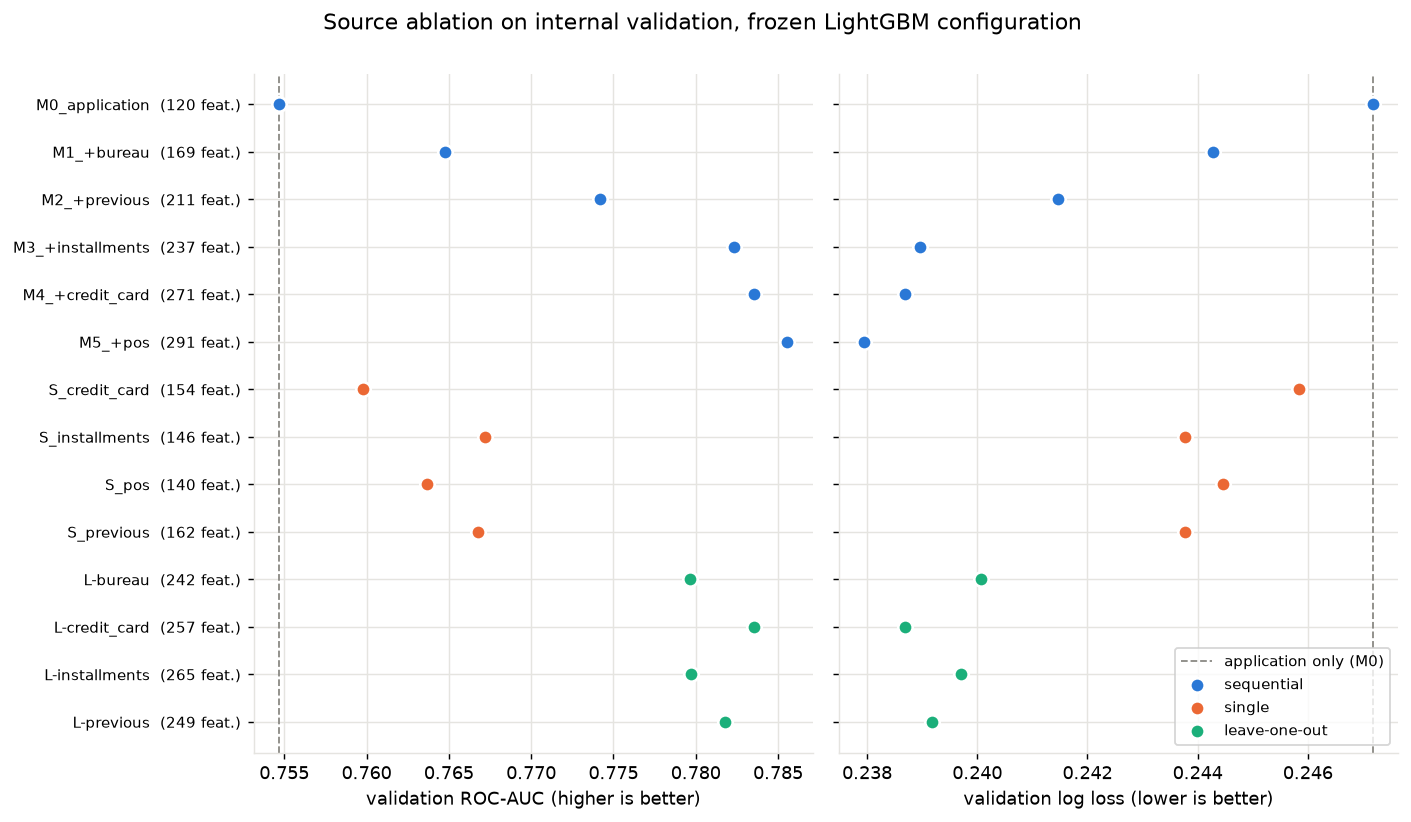

In [5]:
for key, name in [("frozen_membership_sha256", "baseline_split_membership.csv"),
                  ("internal_membership_sha256", "internal_validation_membership.csv")]:
    actual = hashlib.sha256((ROOT / "data/processed" / name).read_bytes()).hexdigest()
    assert actual == repair[key]
ablation = pd.read_csv(METRICS / "relational_ablation.csv")
display(ablation[["configuration", "n_features", "roc_auc", "pr_auc", "log_loss", "brier", "ece", "fit_seconds"]])
display(Image(filename=str(ROOT / "artifacts/figures/relational_ablation_validation.png")))

## Source retention and limited retuning

Backward elimination uses 500 paired validation bootstrap replicates and removal
cost in log loss. Stop when removing even the weakest source has a positive lower
confidence bound. These are selection comparisons on one split, not causal effects
or multiplicity-adjusted evidence. The same small coordinate-search protocol follows;
test outcomes are not used. Sources, preprocessing, parameters, seeds and provenance
are locked before the corrected test stage.

In [6]:
display(pd.DataFrame(selection["source_value"]).T)
display(pd.DataFrame(selection["elimination"]["rounds"][-1]["candidates"]))
display(pd.read_csv(METRICS / "relational_trials.csv"))
print("Retained:", selection["retained_sources"])
print("Changes versus frozen MS2:", selection["retune"]["changed_vs_frozen"])
lock = read("relational_experiment_lock.json")
print("Locked before test scoring:", lock["locked_at_utc"])
display(pd.Series(payload["spec"]["params"], name="final_parameters"))

,history_coverage,n_features,single_source_gain_log_loss,single_source_gain_roc_auc,leave_one_out_cost_log_loss,leave_one_out_cost_roc_auc
bureau,0.856736,49.0,0.002893,0.010087,0.002126,0.005913
previous,0.946449,42.0,0.003410,0.012074,0.001240,0.003782
installments,0.948433,26.0,0.003402,0.012521,0.001765,0.005886
credit_card,0.283255,34.0,0.001342,0.005082,0.000737,0.002043
pos,0.941254,20.0,0.002707,0.009008,0.000745,0.002023


,source,config,removal_cost_log_loss,ci_low,ci_high,removal_cost_roc_auc,roc_auc_ci_low,roc_auc_ci_high,fraction_worse_without
0,bureau,L-bureau,0.002126,0.001539,0.002685,0.005913,0.004093,0.007803,1.000
1,previous,L-previous,0.001240,0.000753,0.001739,0.003782,0.002143,0.005426,1.000
2,installments,L-installments,0.001765,0.001247,0.002330,0.005886,0.004204,0.007705,1.000
3,credit_card,L-credit_card,0.000737,0.000274,0.001221,0.002043,0.000549,0.003625,0.998
4,pos,M4_+credit_card,0.000745,0.000345,0.001112,0.002023,0.000790,0.003176,1.000


,trial_id,library,stage,description,heavy_tail,missing_indicators,n_features,n_trees,early_stopped,fit_seconds,...,val_brier_skill_score,val_expected_calibration_error,val_calibration_slope,val_calibration_intercept,val_mean_predicted_probability,train_roc_auc,train_average_precision,train_log_loss,train_brier_score,params_json
0,lightgbm-01,lightgbm,initial,starting configuration,none,none,291,1947,True,124.18,...,0.108549,0.004907,0.980846,-0.024103,0.079765,0.860305,0.431240,0.209112,0.058953,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.0..."
1,lightgbm-02,lightgbm,search:num_leaves,num_leaves=31,none,none,291,1178,True,91.09,...,0.107987,0.005683,0.976871,-0.025728,0.079343,0.879259,0.482665,0.200941,0.056761,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.0..."
2,lightgbm-03,lightgbm,search:min_child_samples,min_child_samples=100,none,none,291,2681,True,92.59,...,0.107820,0.005427,0.967392,-0.044284,0.079299,0.885668,0.499334,0.198146,0.056045,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.0..."
3,lightgbm-04,lightgbm,search:colsample_bytree,colsample_bytree=0.3,none,none,291,2625,True,124.62,...,0.108004,0.004943,0.970888,-0.040090,0.079498,0.871295,0.458819,0.204333,0.057720,"{""colsample_bytree"": 0.3, ""learning_rate"": 0.0..."
4,lightgbm-05,lightgbm,search:reg_lambda,reg_lambda=10.0,none,none,291,2291,True,124.71,...,0.107653,0.005640,0.975842,-0.033815,0.079742,0.858823,0.428677,0.209552,0.059064,"{""colsample_bytree"": 0.3, ""learning_rate"": 0.0..."


Retained: ['bureau', 'previous', 'installments', 'credit_card', 'pos']
Changes versus frozen MS2: {'colsample_bytree': {'frozen': 0.5, 'retuned': 0.3}, 'n_estimators': {'frozen': 1380, 'retuned': 2625}}
Locked before test scoring: 2026-09-21T18:03:32+00:00


objective            binary
learning_rate          0.02
n_estimators           2625
num_leaves               15
max_depth                -1
min_child_samples       500
subsample               0.8
subsample_freq            1
colsample_bytree        0.3
reg_alpha               0.0
reg_lambda              1.0
random_state             42
n_jobs                    6
verbose                   0
Name: final_parameters, dtype: object

## Frozen test comparison

The same 61,503 test applications are evaluated after the corrected configuration
is locked. Accepted LR and application-only LightGBM models are reloaded and checked
against stored reference metrics. This cohort had already been observed in prior
milestones and recovery; it is not a newly unobserved holdout. No corrected
test-driven feature selection, threshold optimization or calibration was performed.

,model,roc_auc,average_precision,log_loss,brier_score,brier_skill_score,expected_calibration_error
0,Logistic Regression,0.750412,0.235318,0.248205,0.068216,0.080782,0.002090
1,LightGBM,0.762200,0.253806,0.244556,0.067391,0.091900,0.002197
2,LightGBM + history,0.789981,0.294835,0.235325,0.065306,0.119990,0.002096


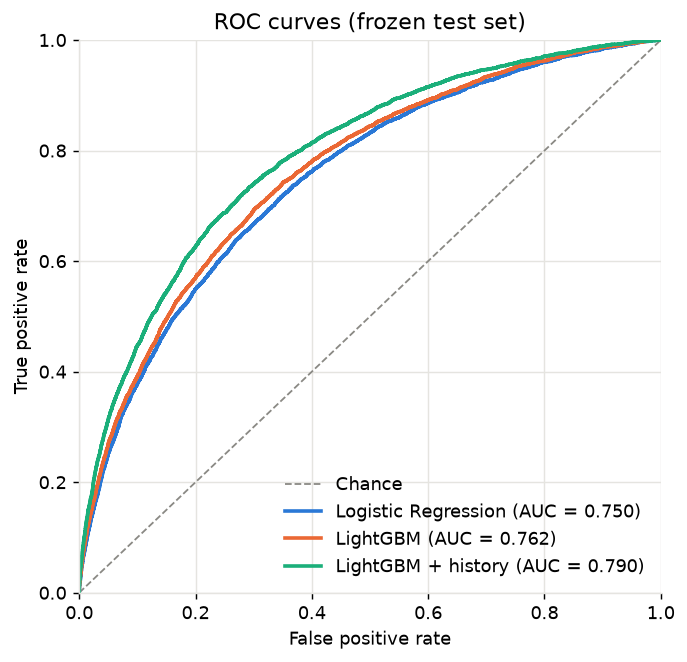

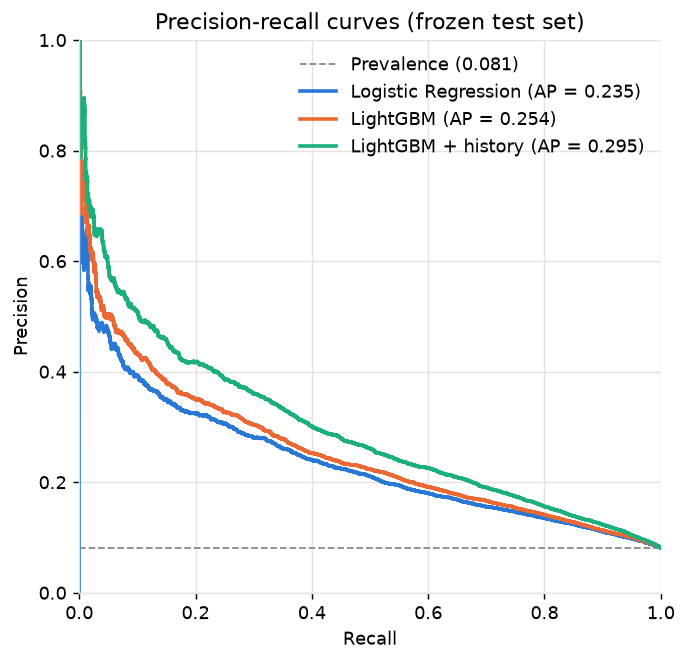

In [7]:
display(final["comparison_table"][["model", "roc_auc", "average_precision", "log_loss", "brier_score", "brier_skill_score", "expected_calibration_error"]])
predictions = pd.read_csv(paths.test_predictions_path)
measured = compute_metrics(predictions["y"], predictions["p_lightgbm_relational"])
for metric in ["roc_auc", "average_precision", "log_loss", "brier_score", "expected_calibration_error"]:
    np.testing.assert_allclose(measured[metric], payload["metrics"]["test"][metric], rtol=0, atol=1e-12)
display(Image(filename=str(ROOT / "artifacts/figures/relational_roc_comparison.png")))
display(Image(filename=str(ROOT / "artifacts/figures/relational_precision_recall_comparison.png")))

## Uncertainty and repair impact

The paired percentile bootstrap uses 1,000 resamples, seed 42, and identical sampled
test rows for both models. It quantifies sampling uncertainty conditional on the
fitted models, not source-selection or time-shift uncertainty. The old metrics below
are explicitly the recovered, unaccepted experiment; all other results are corrected.

,estimate,ci_low,ci_high
roc_auc,0.027781,0.023872,0.031515
average_precision,0.041029,0.033737,0.04869
log_loss,-0.009232,-0.010475,-0.008037
brier_score,-0.002085,-0.002433,-0.001753


,recovered_not_accepted,corrected,corrected_minus_recovered
roc_auc,0.790004,0.789981,-0.000023
average_precision,0.294307,0.294835,0.000527
log_loss,0.235352,0.235325,-0.000027
brier_score,0.065316,0.065306,-0.000010
expected_calibration_error,0.002322,0.002096,-0.000226


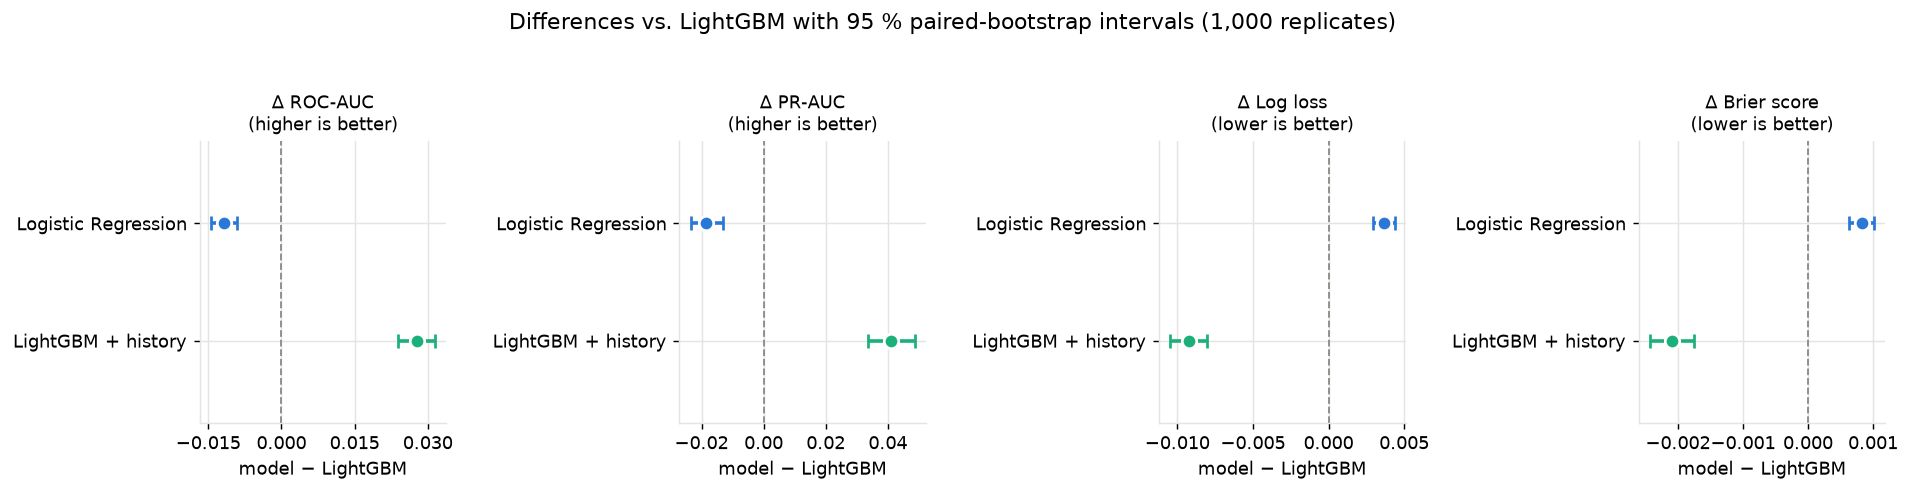

In [8]:
pair = final["bootstrap"]["differences"]["lightgbm_relational_vs_lightgbm"]
display(pd.DataFrame({k: v for k, v in pair.items() if isinstance(v, dict)}).T[["estimate", "ci_low", "ci_high"]])
display(pd.DataFrame({"recovered_not_accepted": repair["pre_repair"]["metrics_test"],
                      "corrected": repair["corrected"]["metrics_test"],
                      "corrected_minus_recovered": repair["corrected_minus_recovered"]}).loc[list(repair["corrected_minus_recovered"])])
display(Image(filename=str(ROOT / "artifacts/figures/relational_delta_bootstrap.png")))

## Calibration

Inspect ECE together with slope/intercept, predicted mean, prevalence and the
ten-bin reliability curve. Small binning estimates need not move monotonically.
These diagnostics do not presently justify formal recalibration; no recalibration
comparison was performed, so they do not rule out benefit under a future population.

expected_calibration_error    0.002096
calibration_slope             1.001652
calibration_intercept         0.011741
mean_predicted_probability    0.080163
prevalence                    0.080728
dtype: float64

,bin,lower,upper,n,mean_predicted,observed_rate,gap
0,0,0.000983,0.013515,6151,0.009666,0.009429,-0.000237
1,1,0.013515,0.019821,6150,0.016649,0.017398,0.000749
2,2,0.019821,0.026696,6150,0.023182,0.020650,-0.002532
3,3,0.026696,0.035035,6150,0.030682,0.029919,-0.000763
4,4,0.035035,0.045684,6150,0.040119,0.040650,0.000531
5,5,0.045684,0.060121,6151,0.052554,0.050236,-0.002319
6,6,0.060121,0.081309,6150,0.070081,0.071220,0.001138
7,7,0.081309,0.117083,6150,0.097572,0.105203,0.007631
8,8,0.117083,0.191358,6150,0.148618,0.151870,0.003252
9,9,0.191358,0.891551,6151,0.312485,0.310681,-0.001804


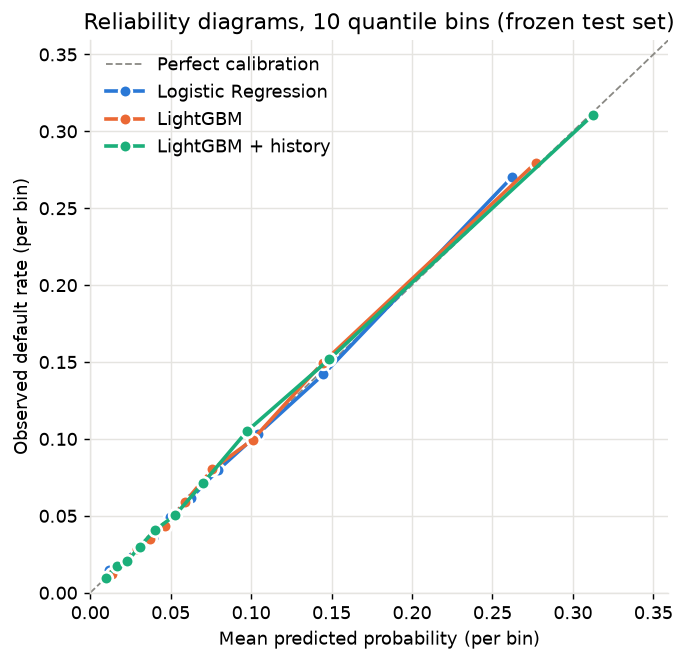

In [9]:
display(pd.Series({k: payload["metrics"]["test"][k] for k in
    ["expected_calibration_error", "calibration_slope", "calibration_intercept", "mean_predicted_probability", "prevalence"]}))
display(pd.DataFrame(payload["calibration_table_test"]))
display(Image(filename=str(ROOT / "artifacts/figures/relational_calibration_comparison.png")))

## Tree usage and conclusion

Gain/split importance shows model usage, not causal attribution. The validation
ablation supplies the source-selection evidence. The corrected comparison improves
discrimination and proper scores over the application-only model while retaining
good descriptive calibration. Temporal semantics, aggregation assumptions, a single
internal split and absence of a time-based external holdout remain limitations.
See the repair report for the complete acceptance checklist; no later milestone
is started by this notebook.

,source,n_features,gain,split,gain_share,split_share,features_used,top_features_by_gain
0,application,120,422228.487263,14736,0.533478,0.400980,103,"EXT_SOURCE_2, EXT_SOURCE_3, ORGANIZATION_TYPE"
1,bureau,49,108725.115674,6804,0.137372,0.185143,46,"bureau__debt_to_credit_ratio, bureau__days_cre..."
2,previous,42,93009.373883,5712,0.117516,0.155429,41,"previous__credit_to_application_ratio_mean, pr..."
3,installments,26,76423.253865,4176,0.096559,0.113633,25,"installments__late_rate_12m, installments__lat..."
4,credit_card,34,45508.682846,2466,0.057499,0.067102,32,"credit_card__utilization_latest_mean, credit_c..."
5,pos,20,45568.887501,2856,0.057575,0.077714,19,"pos__remaining_share_mean, pos__instalments_fu..."


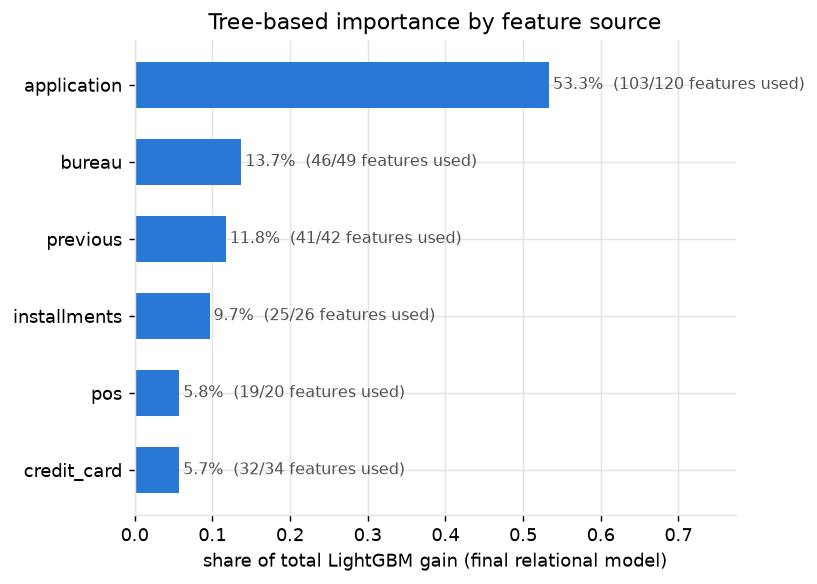

Final fit seconds: 154.04
Verified corrected artifact metrics, source provenance, and frozen memberships.


In [10]:
display(final["importance"])
display(Image(filename=str(ROOT / "artifacts/figures/relational_importance_by_source.png")))
print("Final fit seconds:", payload["model"]["fit_seconds"])
print("Verified corrected artifact metrics, source provenance, and frozen memberships.")